# Preterm Birth EDA — 2021–2023 Train / 2024 Held-Out Test

Exploratory analysis of the cleaned, feature-engineered natality panel produced
by `feature_engineer_natality.py`. Uses `preterm_oe` (obstetric-estimate based)
as the primary target, per the decision documented in
`natality_data_documentation.md` (Section 14).

**Scope discipline:** everything below runs against the **train years
(2021–2023) only**, except the final drift-check section, which compares
*marginal* distributions against the held-out 2024 test set for descriptive
purposes — not to guide any feature or modeling decision. Keeping that
boundary explicit here is what makes the later external-temporal-validation
result trustworthy.

In [5]:
import sys
sys.path.insert(0, r"C:\Users\abiol\projects\Preterm\data")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import feature_engineer_natality as fe

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (8, 4)

DATA_DIR = fe.DATA_DIR          # C:\Users\abiol\projects\Preterm\data
TRAIN_YEARS = fe.TRAIN_YEARS    # [2021, 2022, 2023]
TEST_YEAR = fe.TEST_YEAR        # 2024
TARGET = fe.PRIMARY_TARGET      # "preterm_oe"

In [6]:
train_df = fe.load_years(TRAIN_YEARS, DATA_DIR)
test_df = fe.load_years([TEST_YEAR], DATA_DIR)
train_df.shape, test_df.shape

Loaded years [2021, 2022, 2023]: 10,951,038 rows, 2,037 MB in memory
Loaded years [2024]: 3,638,436 rows, 677 MB in memory


((10951038, 85), (3638436, 85))

## 1. Structural overview

In [7]:
train_df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10951038 entries, 0 to 10951037
Data columns (total 85 columns):
 #   Column                   Dtype   
---  ------                   -----   
 0   gestrec3                 category
 1   combgest                 float32 
 2   oegest_comb              float32 
 3   oegest_r3                category
 4   dob_yy                   Int16   
 5   dob_mm                   Int8    
 6   mager                    Int8    
 7   mrace31                  category
 8   mhisp_r                  category
 9   meduc                    category
 10  dmar                     category
 11  precare                  Int8    
 12  previs                   Int8    
 13  cig_0                    Int8    
 14  cig_1                    Int8    
 15  cig_2                    Int8    
 16  cig_3                    Int8    
 17  bmi                      float32 
 18  wtgain                   Int8    
 19  m_ht_in                  Int8    
 20  rf_pdiab              

In [8]:
train_df.dtypes.value_counts()

Int8        67
float32      3
category     2
Int64        2
Int16        1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
int64        1
category     1
category     1
Name: count, dtype: int64

## 2. Missingness audit — real vs. documented

Compares this run's missingness against the figures already recorded in
`natality_data_documentation.md` Section 14 (from the single-year 2024
cleaning run). A meaningfully different number here — not just ordinary
year-to-year noise — is worth stopping on before trusting any imputation
choice built on top of it.

In [9]:
documented_missing_pct_2024 = {
    "dmar": 11.08, "wtgain": 3.00, "bmi": 2.44, "precare": 1.93,
    "meduc": 1.91, "previs": 1.86, "wic": 1.19, "cig_3": 0.98,
    "m_ht_in": 0.65, "cig_0": 0.50, "cig_1": 0.50, "cig_2": 0.49,
    "rf_inftr": 0.21, "rf_cesar": 0.21, "rf_ppterm": 0.21,
}

missing_pct = (train_df.isna().mean() * 100).sort_values(ascending=False)
compare = missing_pct.rename("missing_pct_train_2021_2023").to_frame()
compare["documented_pct_2024_only"] = compare.index.map(documented_missing_pct_2024)
compare.head(20)

,missing_pct_train_2021_2023,documented_pct_2024_only
dmar,11.346240,11.08
wtgain,2.810364,3.00
bmi,2.122949,2.44
bmi_category,2.122949,NaN
precare,2.055275,1.93
no_prenatal_care,2.055275,NaN
late_prenatal_care,2.055275,NaN
previs,1.985620,1.86
meduc,1.677576,1.91
wic,1.136778,1.19


## 3. Target distribution

Overall preterm_oe rate (train, 2021-2023): 10.4130%
data_year
2021    10.4759%
2022    10.3707%
2023    10.3921%
Name: preterm_oe, dtype: object


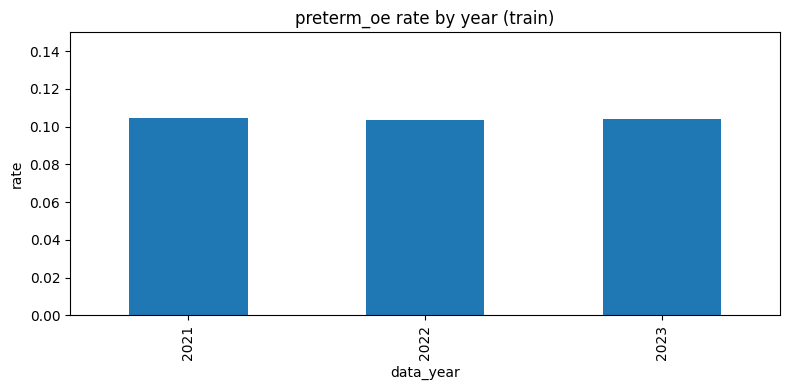

In [10]:
overall_rate = train_df[TARGET].mean()
by_year = train_df.groupby("data_year")[TARGET].mean()
print(f"Overall {TARGET} rate (train, 2021-2023): {overall_rate:.4%}")
print(by_year.apply(lambda x: f"{x:.4%}"))

ax = by_year.plot(kind="bar", title=f"{TARGET} rate by year (train)")
ax.set_ylabel("rate")
ax.set_ylim(0, max(0.15, by_year.max() * 1.2))
plt.tight_layout()
plt.show()

## 4. Missing-not-at-random check

Real (non-imputed) missingness in these NCHS fields tends to cluster by
state/certificate-revision timing rather than occur at random (Section 5 of
the documentation). A cheap first check: does a field's `_reported` flag
correlate with the outcome at all? If it does, mean/mode-imputing the value
column and discarding the flag would quietly throw away real signal — the
`_reported` columns already in this pipeline should be treated as candidate
predictors in their own right, not just preprocessing scaffolding.

In [11]:
fields_to_check = ["dmar", "wtgain", "bmi", "precare", "meduc", "previs", "wic"]
rows = []
for f in fields_to_check:
    reported_col = f"{f}_reported"
    if reported_col not in train_df.columns:
        continue
    grp = train_df.groupby(reported_col, observed=True)[TARGET].agg(["mean", "count"])
    rows.append({
        "field": f,
        "rate_if_reported": grp["mean"].get(1, np.nan),
        "rate_if_not_reported": grp["mean"].get(0, np.nan),
        "n_not_reported": grp["count"].get(0, 0),
    })
pd.DataFrame(rows)

,field,rate_if_reported,rate_if_not_reported,n_not_reported
0,dmar,0.105833,0.091061,1262674
1,wtgain,0.104177,0.081822,22830
2,bmi,0.104177,0.081822,22830
3,precare,0.104177,0.081822,22830
4,meduc,0.104177,0.081822,22830
5,previs,0.104177,0.081822,22830
6,wic,0.104177,0.081822,22830


## 5. Univariate distributions — categorical predictors

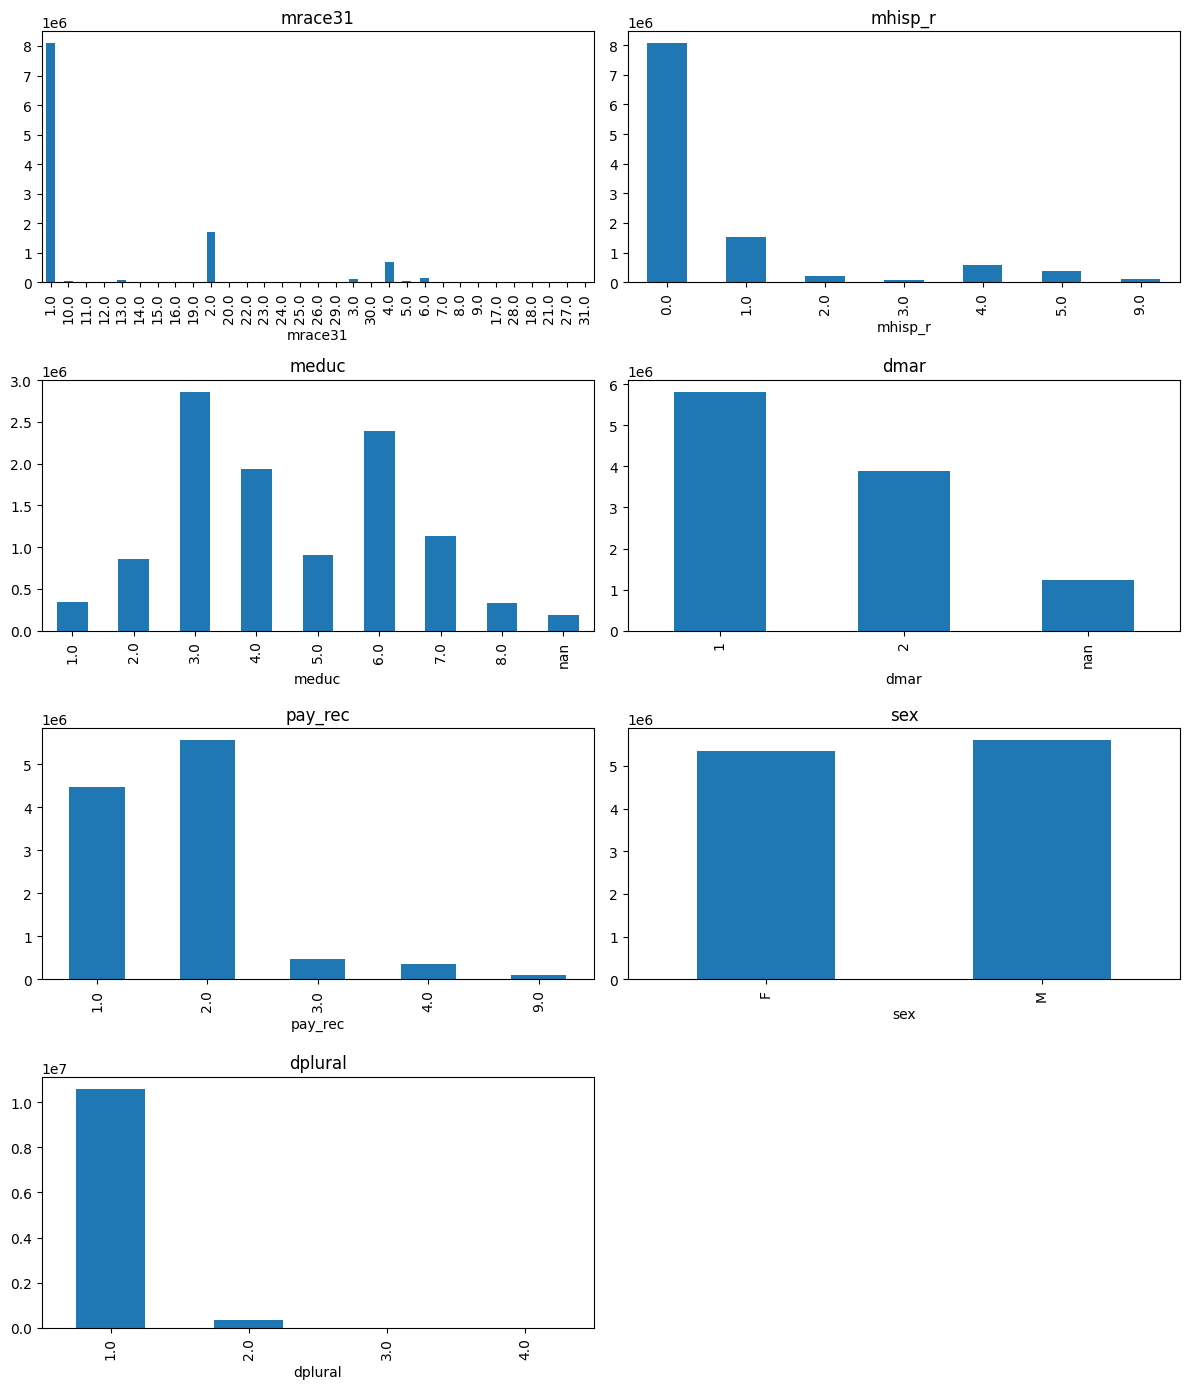

In [12]:
categorical_cols = ["mrace31", "mhisp_r", "meduc", "dmar", "pay_rec", "sex", "dplural"]
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
for ax, col in zip(axes.ravel(), categorical_cols):
    train_df[col].value_counts(dropna=False).sort_index().plot(kind="bar", ax=ax, title=col)
for ax in axes.ravel()[len(categorical_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Univariate distributions — continuous predictors

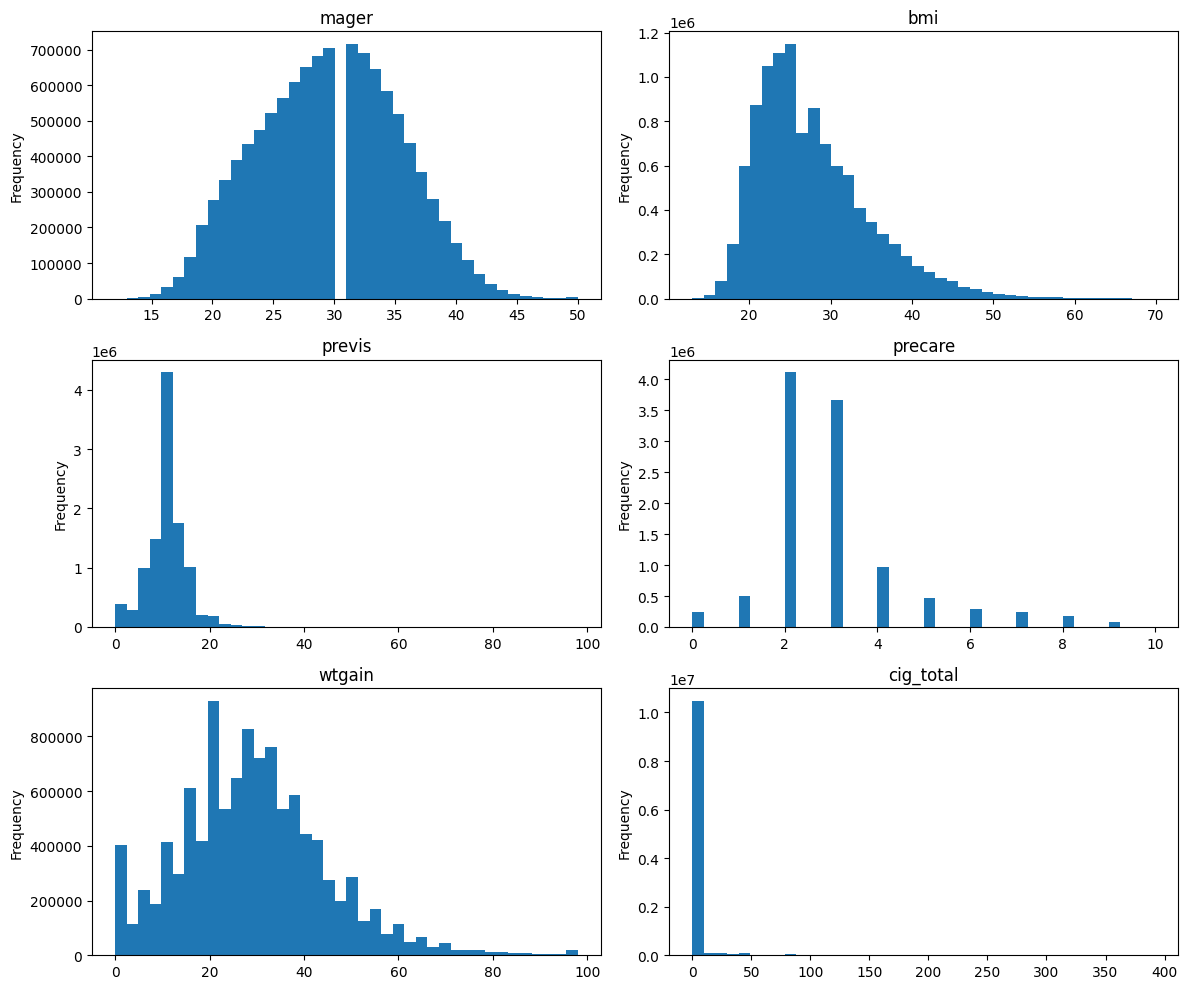

In [13]:
continuous_cols = ["mager", "bmi", "previs", "precare", "wtgain", "cig_total"]
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
for ax, col in zip(axes.ravel(), continuous_cols):
    train_df[col].astype("float32").dropna().plot(kind="hist", bins=40, ax=ax, title=col)
plt.tight_layout()
plt.show()

## 7. Bivariate — preterm_oe rate by predictor

The core signal-finding pass: for each candidate predictor, the `preterm_oe`
rate broken out by category/bin, against the overall base rate as a
reference line. Fields where the rate swings well away from baseline are the
ones modeling will lean on hardest — worth having a prior expectation here
(e.g. prior preterm birth `rf_ppterm` and multiple gestation `dplural` are
established strong clinical risk factors) to sanity-check the eventual model
against, rather than only judging the model by aggregate metrics.

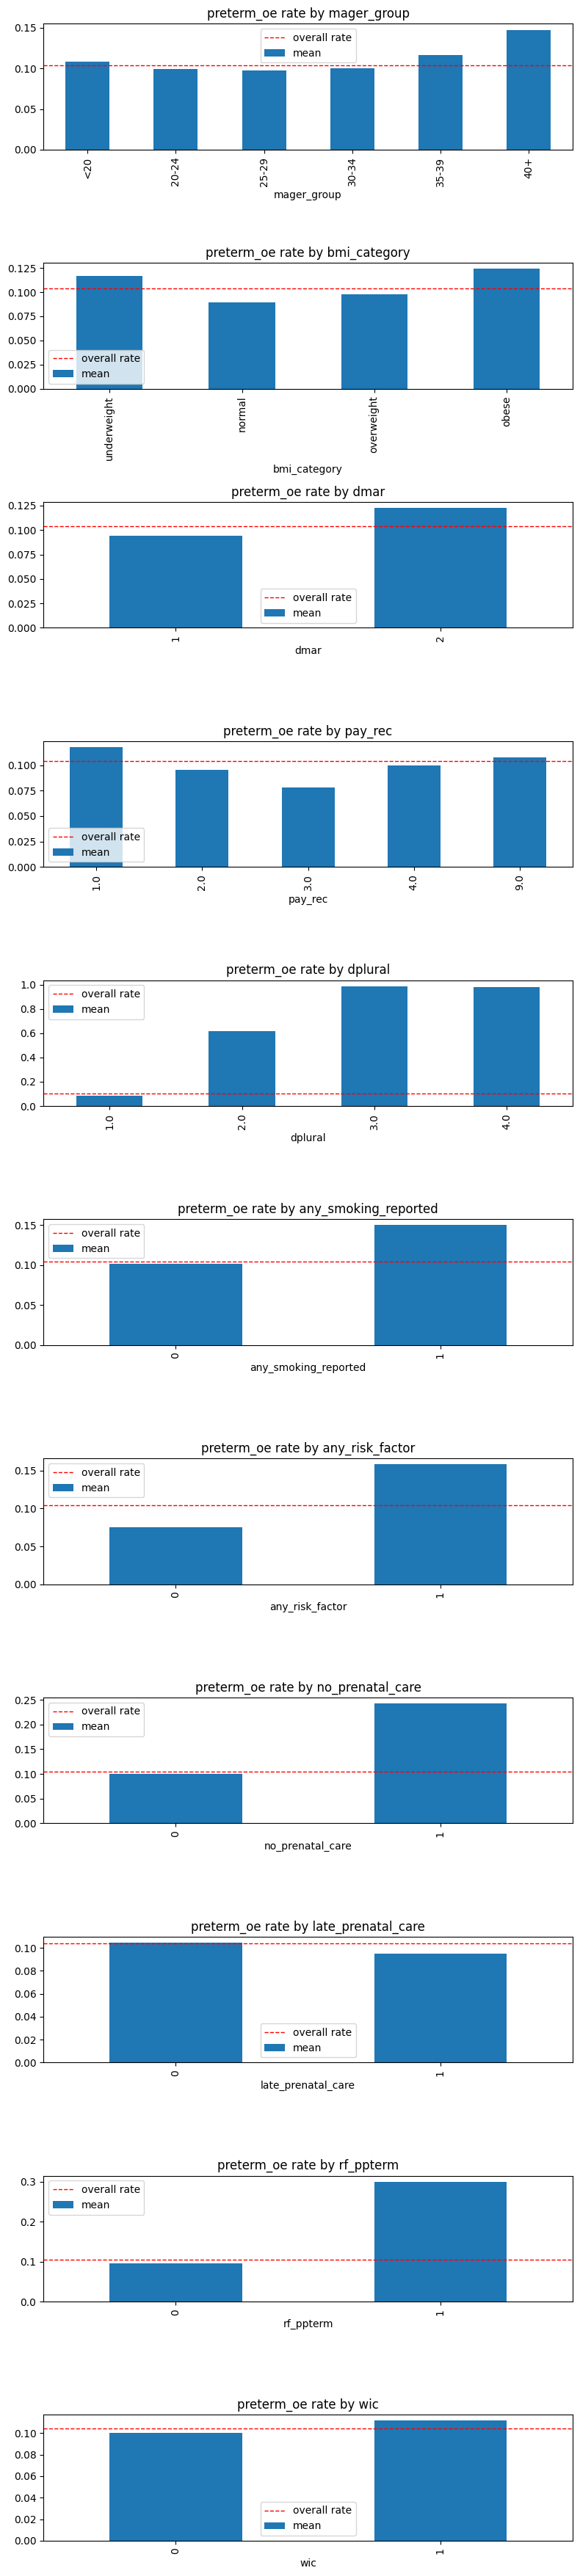

In [14]:
def rate_by(col):
    return train_df.groupby(col, observed=True)[TARGET].agg(["mean", "count"])

bivariate_cols = [
    "mager_group", "bmi_category", "dmar", "pay_rec", "dplural",
    "any_smoking_reported", "any_risk_factor", "no_prenatal_care",
    "late_prenatal_care", "rf_ppterm", "wic",
]
baseline = train_df[TARGET].mean()

fig, axes = plt.subplots(len(bivariate_cols), 1, figsize=(8, 3.2 * len(bivariate_cols)))
for ax, col in zip(axes, bivariate_cols):
    rate_by(col)["mean"].plot(kind="bar", ax=ax, title=f"{TARGET} rate by {col}")
    ax.axhline(baseline, color="red", linestyle="--", linewidth=1, label="overall rate")
    ax.legend()
plt.tight_layout()
plt.show()

## 8. Correlation among continuous predictors

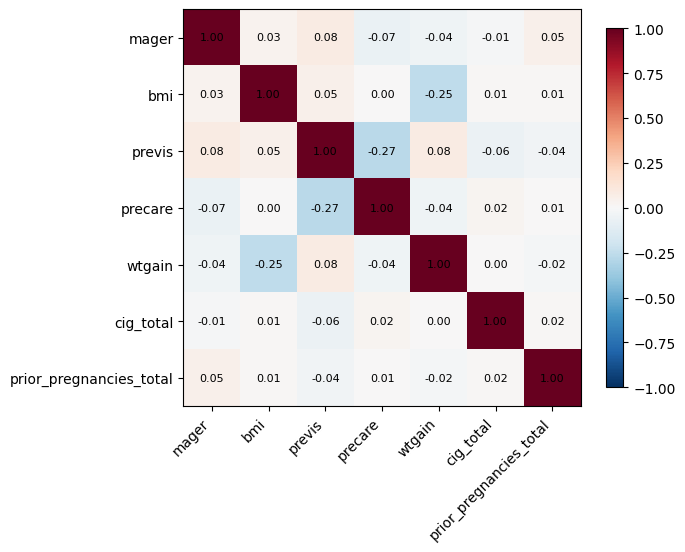

In [15]:
corr_cols = ["mager", "bmi", "previs", "precare", "wtgain", "cig_total", "prior_pregnancies_total"]
corr = train_df[corr_cols].astype("float32").corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()

## 9. Train vs. held-out 2024 — distribution drift check

Descriptive only. Comparing marginal predictor distributions between train
and the external test year is a legitimate, standard part of EDA for a
chronological validation design — it checks whether 2024 looks like a
meaningfully different population, which would matter for interpreting test
performance later. This is different from looking at how 2024's *target*
relates to any predictor, which stays out of scope until actual model
evaluation.

In [16]:
drift_cols = ["mager", "bmi", "previs", "precare", "wtgain"]
drift = pd.DataFrame({
    "train_mean": train_df[drift_cols].astype("float32").mean(),
    "test_2024_mean": test_df[drift_cols].astype("float32").mean(),
})
drift["abs_diff"] = (drift["train_mean"] - drift["test_2024_mean"]).abs()
drift

,train_mean,test_2024_mean,abs_diff
mager,29.501055,29.670700,0.169645
bmi,27.775991,27.903194,0.127203
previs,10.975330,10.910488,0.064842
precare,2.930262,2.986010,0.055748
wtgain,29.227566,29.434793,0.207228


In [17]:
for col in ["dplural", "dmar", "pay_rec"]:
    print(f"\n--- {col} ---")
    comp = pd.DataFrame({
        "train": train_df[col].value_counts(normalize=True, dropna=False).sort_index(),
        "test_2024": test_df[col].value_counts(normalize=True, dropna=False).sort_index(),
    })
    print(comp)

print("\n--- missingness rate: train vs 2024 (top 15 by drift) ---")
miss_compare = pd.DataFrame({
    "train_missing_pct": train_df.isna().mean() * 100,
    "test_2024_missing_pct": test_df.isna().mean() * 100,
})
miss_compare["abs_diff_pts"] = (miss_compare["train_missing_pct"] - miss_compare["test_2024_missing_pct"]).abs()
miss_compare.sort_values("abs_diff_pts", ascending=False).head(15)


--- dplural ---
            train  test_2024
dplural                     
1.0      0.968191   0.969199
2.0      0.031031   0.030088
3.0      0.000739   0.000673
4.0      0.000039   0.000040

--- dmar ---
         train  test_2024
dmar                     
1     0.531048   0.536147
2     0.355490   0.353100
NaN   0.113462   0.110753

--- pay_rec ---
            train  test_2024
pay_rec                     
1.0      0.408484   0.397348
2.0      0.508023   0.513015
3.0      0.042211   0.048606
4.0      0.033250   0.032718
9.0      0.008032   0.008313

--- missingness rate: train vs 2024 (top 15 by drift) ---


,train_missing_pct,test_2024_missing_pct,abs_diff_pts
bmi,2.122949,2.443083,0.320133
bmi_category,2.122949,2.443083,0.320133
dmar,11.346240,11.075253,0.270986
meduc,1.677576,1.909859,0.232283
wtgain,2.810364,2.996232,0.185869
no_prenatal_care,2.055275,1.930005,0.125270
late_prenatal_care,2.055275,1.930005,0.125270
precare,2.055275,1.930005,0.125270
previs,1.985620,1.861377,0.124243
m_ht_in,0.541958,0.649785,0.107827


## Summary — EDA findings and what they mean for the model notebook

**Target rate is stable and the primary-target choice holds up.** Overall
`preterm_oe` rate across all four years is 10.41%, and it barely moves
year to year (2021 10.48%, 2022 10.37%, 2023 10.39%, 2024 10.39%) — in line
with the rates documented in `natality_data_documentation.md`. Nothing here
argues against using 2024 as a clean external test year; the base rate
mothers actually experienced didn't shift, so a drop in test-year
performance later would point to something in the *model*, not a moved
target.

**Missingness matches the documented rates, with a small, consistent upward
drift into 2024 on a handful of fields.** `dmar`, `wtgain`, `bmi`,
`precare`, `meduc`, `previs`, `wic`, `cig_0/1/2/3`, and `m_ht_in` all land
close to the percentages in Section 14 of the documentation. The
train-vs-2024 comparison (second-to-last cell above) shows `bmi`, `meduc`,
`wtgain`, `m_ht_in`, and the `cig_*` fields creeping mildly higher in
missingness by 2024 — not a big jump, but a real, one-directional drift
worth tracking rather than dismissing as noise. **Action taken:** the model
notebook's Section 14 (drift) now checks missingness-*rate* drift
explicitly, not just the distribution of non-missing values (its PSI
function drops NaNs before comparing, so it was structurally blind to this
exact finding).

**The missing-not-at-random check surfaced a striking result:** `wtgain`,
`bmi`, `precare`, `meduc`, `previs`, and `wic` are not missing
independently of each other — 22,830 rows in the training years share the
*exact same* not-reported pattern across all six fields simultaneously.
That's almost certainly one operational cause (e.g. an intake form section
left blank) rather than six separate reasons a field went unrecorded, and
each field's individual missingness is consistently associated with a
*lower* `preterm_oe` rate. **Action taken:** the model notebook now
explicitly checks correlation among the `*_reported` flags themselves
(not just each flag against its own source `f_*` column), right after the
existing correlation screen in Section 2 — confirming this batch-missingness
pattern on the actual feature matrix before the SHAP/importance sections
are read at face value.

**Bivariate pass: `dplural` dominates everything else, `rf_ppterm` is a
distant second, and `late_prenatal_care` is a near-null/inverted signal
worth explaining rather than trusting.** The bar chart shows preterm rate
climbing from ~7% for singletons to ~60–65% for twins and ~95–100% for
triplets/quadruplets — by far the strongest predictor in the dataset, which
is expected clinically (multiple gestation mechanically shortens most
pregnancies) but means a headline AUC/F1 could be substantially propped up
by this one field rather than reflecting genuine risk-stratification within
the much more common singleton population. `rf_ppterm` (prior preterm
birth) is the strongest non-plurality predictor, roughly ~9% → ~30%.
`bmi_category` and `mager_group` both show the expected clinical U-shapes
(elevated risk at both low and high BMI/maternal age). `late_prenatal_care`
shows a surprising near-null or slightly inverted relationship with
`preterm_oe` — this is very likely reverse censoring: a pregnancy that ends
very early preterm mechanically shortens the window in which "late-starting"
prenatal care could ever be recorded, so the most severe preterm cases are
under-represented in that flag rather than genuinely low-risk. **Actions
taken:** (1) added a singleton-only (`dplural == 1`) subgroup cut right
after the main 2024 evaluation (Section 8b), so the headline metrics can be
checked against performance on the harder, far more common non-multiple-
gestation case; (2) added a markdown caution note near feature
importance/SHAP explaining the `late_prenatal_care` reverse-censoring
mechanism, so a low ranking there isn't mistaken for the model missing
signal it never had access to.

**Continuous-predictor correlations are clean.** The 7×7 heatmap shows no
concerning multicollinearity among `mager`, `bmi`, `previs`, `precare`,
`wtgain`, and related continuous fields — nothing here calls for dropping a
feature purely on redundancy grounds; LightGBM is robust to whatever mild
correlation does exist.

**Train (2021–2023) vs. 2024 drift is negligible outside of the missingness
finding above.** Continuous-field means, and the categorical proportions for
`dplural`, `dmar`, and `pay_rec`, are all close between train and 2024 — no
distributional shift big enough on its own to expect a meaningful drop in
model performance going into the external test year.

**Net effect on the model notebook (`02_model_build_natality_preterm.ipynb`):**
1. Section 2 — added a correlation check among the `*_reported` flags
   themselves, confirming the six-field batch-missingness pattern on the
   real feature matrix.
2. Section 8b (new) — singleton-only (`dplural == 1`) subgroup evaluation,
   run right after the main 2024 evaluation, to separate genuine
   risk-stratification from the `dplural` effect.
3. Feature importance / SHAP — added a caution note explaining why
   `late_prenatal_care` is expected to rank low (reverse censoring), so it
   isn't misread as a modeling gap.
4. Section 14 (drift) — extended beyond PSI-on-non-missing-values to also
   check missingness-*rate* drift directly, since that's the real drift
   this EDA found and the PSI function alone couldn't see it.

No changes were made to the target choice, the train/test year split, or
the leakage-column list — nothing in this EDA pass calls any of those into
question.
